In [30]:
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

ecg_signal = record.p_signal[:, 0]   # first channel
fs = record.fs                       # sampling frequency
print("Signal length:", len(ecg_signal), "| Sampling rate:", fs)

Signal length: 650000 | Sampling rate: 360


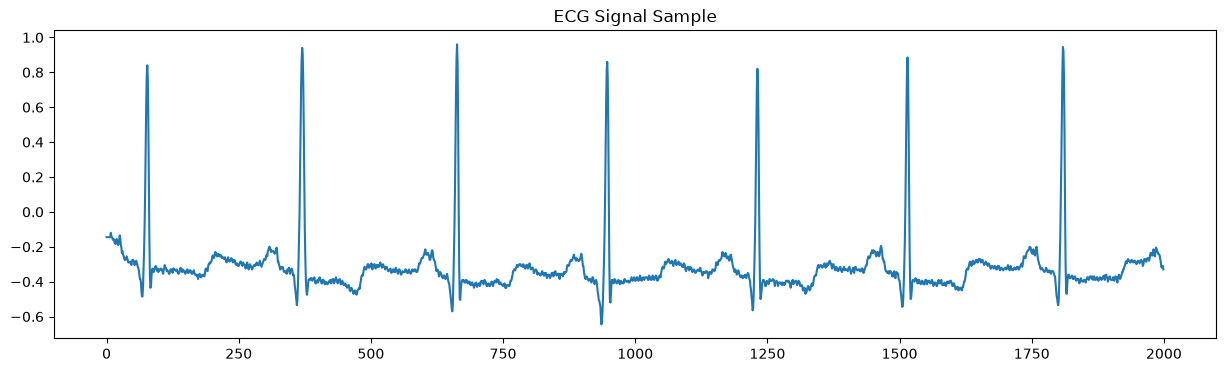

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(ecg_signal[:2000])
plt.title("ECG Signal Sample")
plt.show()

In [32]:
import wfdb

# Try a handful of mitdb records
mitdb_records = ['100', '101', '200', '201', '203', '210', '219', '221']

for rec_name in mitdb_records:
    try:
        ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')
        rhythms_found = set(ann.aux_note) - {''}
        print(f"Record {rec_name}: {rhythms_found}")
    except Exception as e:
        print(f"Record {rec_name}: failed ({e})")

Record 100: {'(N\x00'}
Record 101: {'(N\x00'}
Record 200: {'(VT\x00', '(N\x00', '(B\x00'}
Record 201: {'(N', '(T\x00', '(N\x00', '(NOD\x00', '(AFIB\x00', '(SVTA'}
Record 203: {'(T\x00', '(AFL\x00', '(VT\x00', '(AFIB\x00'}
Record 210: {'(T\x00', '(VT\x00', '(AFIB\x00', '(B\x00'}
Record 219: {'(B\x00', '(T\x00', '(N\x00', 'MISSB\x00', '(AFIB\x00', 'PSE\x00'}
Record 221: {'(T\x00', '(VT\x00', '(AFIB\x00', '(B\x00'}


**Denoising**


In [17]:
from scipy.signal import butter, filtfilt, iirnotch

def denoise_ecg(ecg, fs):
    """
    Truth sheet ke exact numbers: 0.5-150 Hz bandpass + 50Hz notch
    """
    nyquist = fs / 2

    # Step 1: Bandpass filter (0.5 - 150 Hz)
    low = 0.5 / nyquist
    high = min(150 / nyquist, 0.99)   # fs kam hai to 150Hz nyquist se upar na chala jaye
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, ecg)

    # Step 2: 50Hz notch filter (powerline hum hatane ke liye)
    notch_freq = 50 / nyquist
    if notch_freq < 1.0:   # sirf tab lagao agar sampling rate ijazat de
        b_notch, a_notch = iirnotch(50, Q=30, fs=fs)
        filtered = filtfilt(b_notch, a_notch, filtered)

    return filtered

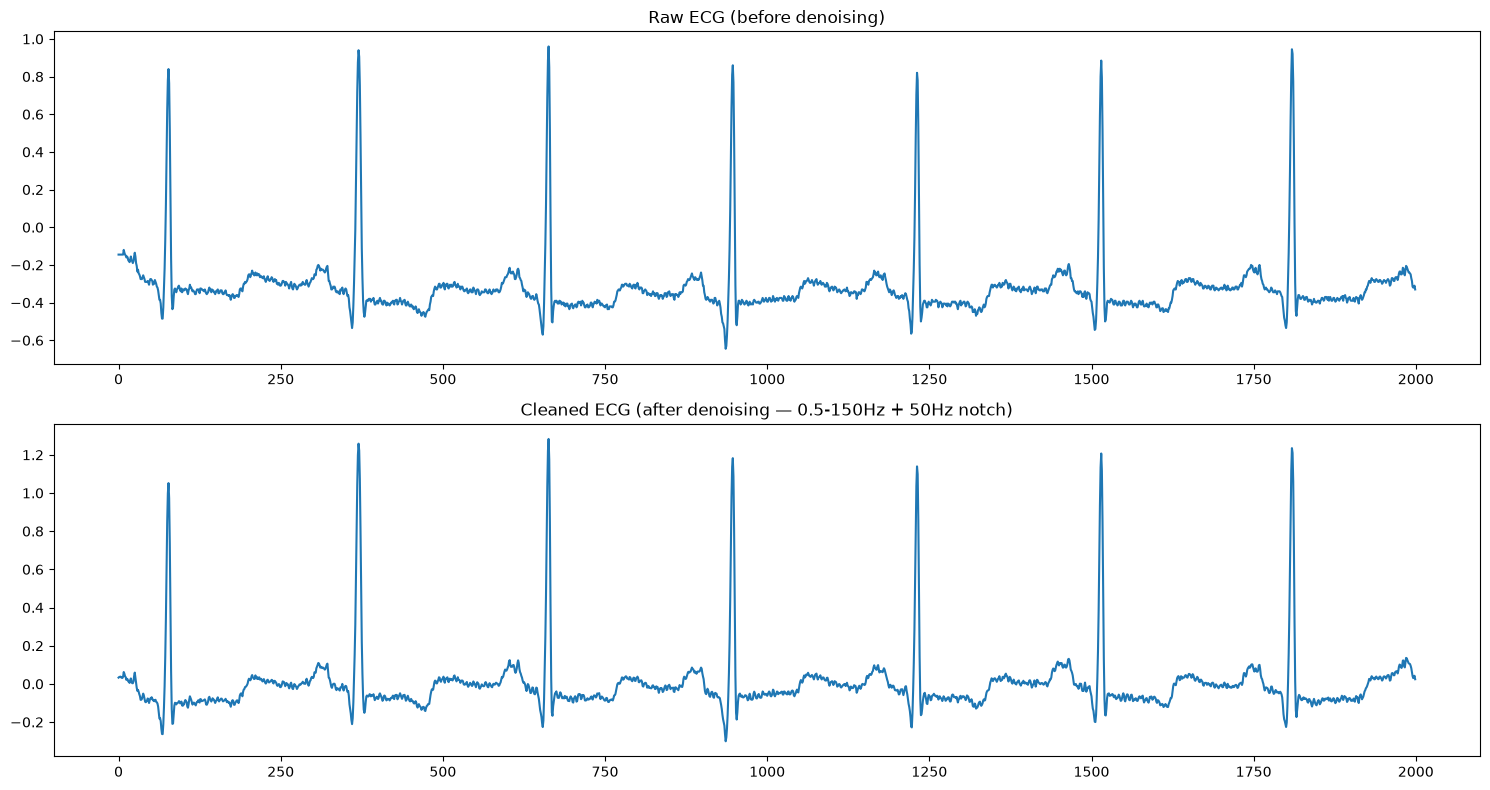

In [18]:
import matplotlib.pyplot as plt

raw_sample = ecg_signal[:2000]
cleaned_sample = denoise_ecg(raw_sample, fs)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(raw_sample)
axes[0].set_title("Raw ECG (before denoising)")
axes[1].plot(cleaned_sample)
axes[1].set_title("Cleaned ECG (after denoising — 0.5-150Hz + 50Hz notch)")
plt.tight_layout()
plt.show()

In [19]:
import wfdb
from collections import Counter

# MIT-BIH ke saare 48 record numbers
all_mitdb_records = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

record_rhythm_summary = {}

for rec_name in all_mitdb_records:
    try:
        ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')
        rhythms = [a.rstrip('\x00') for a, sym in zip(ann.aux_note, ann.symbol) if sym == '+']
        counts = Counter(rhythms)
        record_rhythm_summary[rec_name] = counts
    except Exception as e:
        print(f"Record {rec_name}: skip ({e})")

# Ab dekho konse records mein '(B' (brady) ya '(T' (tachy) hain
print("\n=== Records with Bradycardia ('(B') episodes ===")
for rec, counts in record_rhythm_summary.items():
    if '(B' in counts:
        print(f"Record {rec}: {counts['(B']} episodes")

print("\n=== Records with Tachycardia ('(T') episodes ===")
for rec, counts in record_rhythm_summary.items():
    if '(T' in counts:
        print(f"Record {rec}: {counts['(T']} episodes")


=== Records with Bradycardia ('(B') episodes ===
Record 106: 18 episodes
Record 119: 37 episodes
Record 200: 71 episodes
Record 207: 4 episodes
Record 210: 5 episodes
Record 213: 19 episodes
Record 217: 9 episodes
Record 219: 2 episodes
Record 221: 1 episodes
Record 223: 7 episodes
Record 228: 20 episodes
Record 233: 28 episodes

=== Records with Tachycardia ('(T') episodes ===
Record 106: 1 episodes
Record 119: 17 episodes
Record 124: 2 episodes
Record 201: 12 episodes
Record 203: 1 episodes
Record 208: 26 episodes
Record 210: 1 episodes
Record 214: 10 episodes
Record 219: 1 episodes
Record 221: 8 episodes
Record 223: 3 episodes
Record 233: 1 episodes


**Extraction of HRV Features**


In [28]:
import neurokit2 as nk
import numpy as np

def extract_hrv_features(rpeaks_times, fs):
    """
    rpeaks_times: R-peak ke timestamps (seconds mein), jo tumhare 
                   detect_rpeaks() function se aa rahe hain
    fs: sampling frequency
    Returns: dictionary of HRV features for ek recording
    """
    # R-peak times ko samples mein convert karo (neurokit ko samples chahiye)
    rpeaks_samples = (np.array(rpeaks_times) * fs).astype(int)
    
    # RR intervals nikalo (consecutive R-peaks ka difference, milliseconds mein)
    rr_intervals = np.diff(rpeaks_samples) / fs * 1000  # ms mein
    
    if len(rr_intervals) < 2:
        # Agar bohot kam beats hain to safe default return karo
        return {
            "mean_RR": np.nan, "SDNN": np.nan, "RMSSD": np.nan,
            "min_RR": np.nan, "max_RR": np.nan
        }
    
    mean_rr = np.mean(rr_intervals)
    sdnn = np.std(rr_intervals)  # variation kitna hai
    rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))  # irregularity (afib ke liye important)
    min_rr = np.min(rr_intervals)
    max_rr = np.max(rr_intervals)
    
    return {
        "mean_RR": mean_rr,
        "SDNN": sdnn,
        "RMSSD": rmssd,
        "min_RR": min_rr,
        "max_RR": max_rr
    }

In [29]:
import wfdb
import numpy as np
import neurokit2 as nk
from scipy.signal import butter, filtfilt, iirnotch
from collections import Counter

def denoise_ecg(ecg, fs):
    nyquist = fs / 2
    low = 0.5 / nyquist
    high = min(150 / nyquist, 0.99)
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, ecg)

    notch_freq = 50 / nyquist
    if notch_freq < 1.0:
        b_notch, a_notch = iirnotch(50, Q=30, fs=fs)
        filtered = filtfilt(b_notch, a_notch, filtered)

    return filtered

records = [
    '100', '101', '106', '119', '124', '200', '201', '203',
    '207', '208', '210', '213', '214', '219', '221',
    '223', '228', '233'
]   # 217 (paced beats) hata diya

target_map = {
    '(N': 'normal',
    '(B': 'brady',
    '(T': 'tachy',
    '(AFIB': 'afib'
}

window_sec = 5
all_features = []
all_labels = []

for rec_name in records:
    try:
        record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
        ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')
    except Exception as e:
        print(f"Record {rec_name}: skip ({e})")
        continue

    ecg = record.p_signal[:, 0]
    fs = record.fs

    rhythm_points = [(s, a.rstrip('\x00')) for s, a, sym in zip(ann.sample, ann.aux_note, ann.symbol) if sym == '+']
    if not rhythm_points:
        continue
    rhythm_points.append((len(ecg), None))

    for i in range(len(rhythm_points) - 1):
        start_sample, rhythm_label = rhythm_points[i]
        end_sample, _ = rhythm_points[i + 1]

        clean_label = target_map.get(rhythm_label)
        if clean_label is None:
            continue

        window_samples = int(window_sec * fs)
        for w_start in range(start_sample, end_sample - window_samples, window_samples):
            w_end = w_start + window_samples
            segment = ecg[w_start:w_end]
            try:
                cleaned_segment = denoise_ecg(segment, fs)
                signals, info = nk.ecg_process(cleaned_segment, sampling_rate=fs)
                r_peaks = info['ECG_R_Peaks']
                if len(r_peaks) < 5:
                    continue
                rr_intervals = np.diff(r_peaks) / fs
                avg_hr = 60 / np.mean(rr_intervals)
                rr_std = np.std(rr_intervals)
                rr_min = np.min(rr_intervals)
                rr_max = np.max(rr_intervals)
                rr_range = rr_max - rr_min

                # ---- NAYA: RMSSD (irregularity ka best measure — afib ke liye critical) ----
                rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))

                all_features.append([avg_hr, rr_std, rr_min, rr_max, rr_range, rmssd])
                all_labels.append(clean_label)
            except Exception:
                continue

print("Total samples collected:", len(all_features))
print("Label counts:", Counter(all_labels))

c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neu

Total samples collected: 5150
Label counts: Counter({'normal': 3333, 'afib': 1364, 'brady': 325, 'tachy': 128})


In [33]:
def detect_rpeaks(ecg, fs):
    cleaned = denoise_ecg(ecg, fs)
    signals, info = nk.ecg_process(cleaned, sampling_rate=fs)
    r_peak_samples = info['ECG_R_Peaks']
    times = [i / fs for i in r_peak_samples]
    return times

In [34]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

X = np.array(all_features)
y = np.array(all_labels)

# Sabhi models ke liye same custom class weights (jo humne pehle decide kiye the)
class_weights = {
    'normal': 1,
    'afib': 1,
    'brady': 3,
    'tachy': 5
}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight=class_weights),
    "SVM": SVC(class_weight=class_weights),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)   # KNN class_weight support nahi karta, isliye chhoda
}

print("=== Model Comparison (5-fold Cross-Validation Accuracy) ===\n")
results = {}

for name, model in models.items():
    data_to_use = X if name == "Random Forest" else X_scaled   # RF ko scaling ki zaroorat nahi
    scores = cross_val_score(model, data_to_use, y, cv=5)
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

print("\n=== Best Model ===")
best_model_name = max(results, key=results.get)
print(f"{best_model_name} with average accuracy: {results[best_model_name]:.3f}")

=== Model Comparison (5-fold Cross-Validation Accuracy) ===

Random Forest: 0.661 (+/- 0.103)
Logistic Regression: 0.590 (+/- 0.083)
SVM: 0.654 (+/- 0.094)
K-Nearest Neighbors: 0.686 (+/- 0.088)

=== Best Model ===
K-Nearest Neighbors with average accuracy: 0.686


In [35]:
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights)
rf.fit(X_train, y_train)
print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test)))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("=== K-Nearest Neighbors ===")
print(classification_report(y_test, knn.predict(X_test_scaled)))

=== Random Forest ===
              precision    recall  f1-score   support

        afib       0.67      0.68      0.68       341
       brady       0.76      0.64      0.70        81
      normal       0.85      0.86      0.85       834
       tachy       0.38      0.44      0.41        32

    accuracy                           0.79      1288
   macro avg       0.67      0.65      0.66      1288
weighted avg       0.79      0.79      0.79      1288

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

        afib       0.69      0.74      0.71       341
       brady       0.77      0.69      0.73        81
      normal       0.88      0.87      0.88       834
       tachy       0.61      0.44      0.51        32

    accuracy                           0.81      1288
   macro avg       0.74      0.68      0.71      1288
weighted avg       0.81      0.81      0.81      1288



=== Final Classification Report ===
              precision    recall  f1-score   support

        afib       0.66      0.66      0.66       341
       brady       0.60      0.63      0.61        81
      normal       0.85      0.85      0.85       834
       tachy       0.45      0.44      0.44        32

    accuracy                           0.77      1288
   macro avg       0.64      0.64      0.64      1288
weighted avg       0.77      0.77      0.77      1288



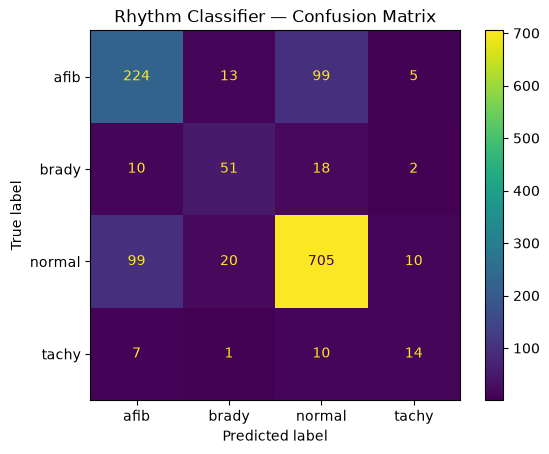

In [26]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Agar Random Forest jeeta (zyada chance hai is data ke liye):
rhythm_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=class_weights
)
rhythm_model.fit(X_train, y_train)

y_pred = rhythm_model.predict(X_test)

print("=== Final Classification Report ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Rhythm Classifier — Confusion Matrix")
plt.show()


def classify_rhythm(feat):
    feat = np.array(feat).reshape(1, -1)
    pred = rhythm_model.predict(feat)[0]
    conf = rhythm_model.predict_proba(feat).max()
    return pred, conf